In [13]:
import matplotlib.pyplot as plt
import numpy as np

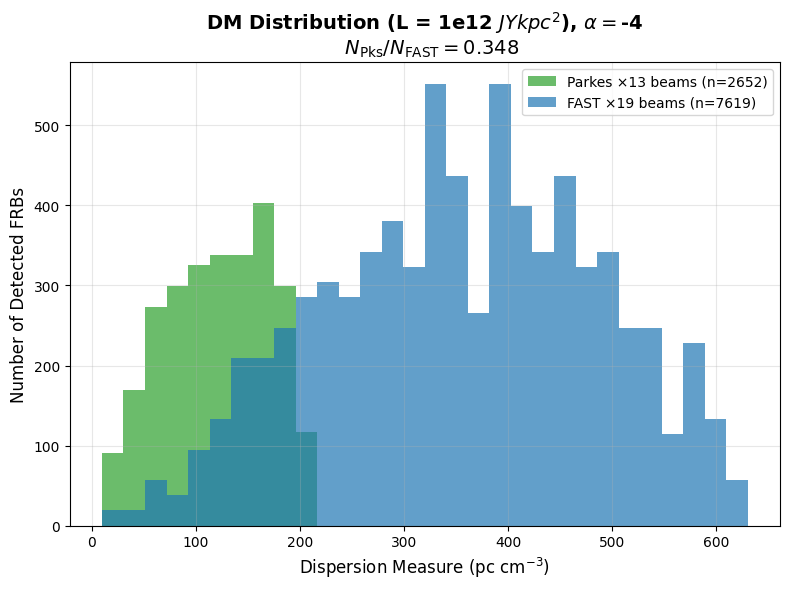

In [14]:
alpha = -4

DM_fast = np.load(f'dm_detected_fast_{alpha}_std.npy')
DM_pks  = np.load(f'dm_detected_PKS_{alpha}_std.npy')

N_FAST_BEAMS = 19
N_PKS_BEAMS  = 13

dm_min = min(DM_fast.min(), DM_pks.min())
dm_max = max(DM_fast.max(), DM_pks.max())   # <-- also fixed your bug here
common_bins = np.linspace(dm_min, dm_max, 31)

plt.figure(figsize=(8, 6), dpi=100)

plt.hist(DM_pks,  bins=common_bins, color='tab:green', alpha=0.7,
         weights=np.full(len(DM_pks),  N_PKS_BEAMS),
         label=f'Parkes ×{N_PKS_BEAMS} beams (n={len(DM_pks)*N_PKS_BEAMS})')
plt.hist(DM_fast, bins=common_bins, color='tab:blue',  alpha=0.7,
         weights=np.full(len(DM_fast), N_FAST_BEAMS),
         label=f'FAST ×{N_FAST_BEAMS} beams (n={len(DM_fast)*N_FAST_BEAMS})')

plt.xlabel('Dispersion Measure (pc cm$^{-3}$)', fontsize=12)
plt.ylabel('Number of Detected FRBs', fontsize=12)
ratio = (len(DM_pks) * N_PKS_BEAMS) / (len(DM_fast) * N_FAST_BEAMS)

# plt.title(f'DM Distribution, $\\alpha=${alpha}\n  '
#           f'$N_{{\\rm Pks}}/N_{{\\rm FAST}}={ratio:.3f}$',
#           fontsize=14, fontweight='bold')
plt.title(f'DM Distribution (L = 1e12 $JY  kpc^{2}$), $\\alpha=${alpha}\n  '
          f'$N_{{\\rm Pks}}/N_{{\\rm FAST}}={ratio:.3f}$',
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()